In [1]:
import matplotlib.pyplot as plt
import sys
sys.path.append("..")
from src import plots

In [2]:
print(plt.style.available)
plt.style.use(["seaborn-v0_8", "seaborn-v0_8-darkgrid", "seaborn-v0_8-notebook"])
## set grid to be dashed
# plt.rcParams["grid.linestyle"] = "--"

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


In [3]:
def cobb_douglas(capital, labor, a=1, alpha=0.3, labor_efficiency=1, **kwargs):
    return a * (capital**alpha) * ((labor * labor_efficiency) ** (1 - alpha))

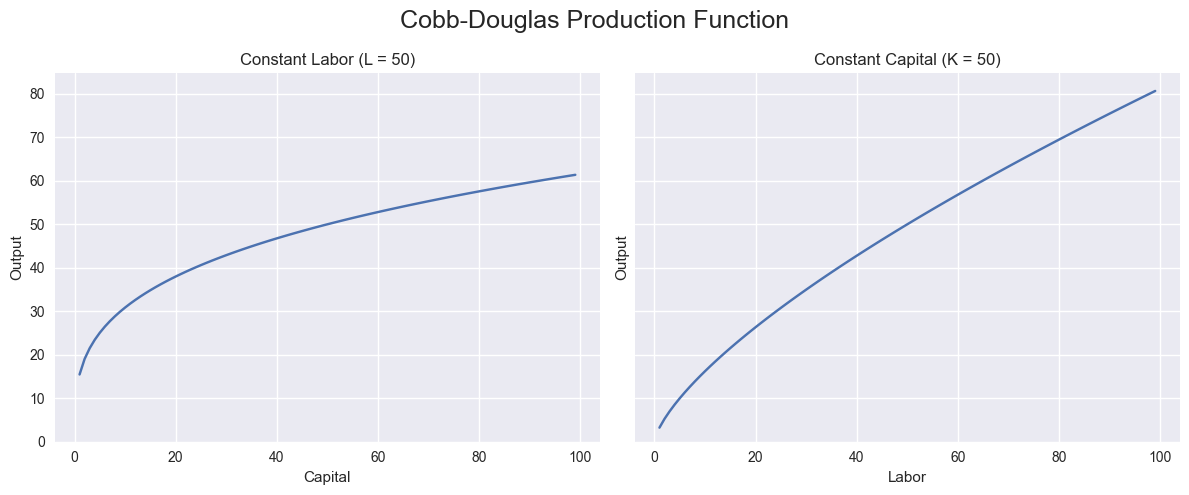

In [4]:
capital_values = range(1, 100)
labor_values = range(1, 100)

# constant labor
labor = 50
output_const_labor = [cobb_douglas(k, labor) for k in capital_values]

# constant capital
capital = 50
output_const_capital = [cobb_douglas(capital, l) for l in labor_values]

y_max = max(max(output_const_labor), max(output_const_capital))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

ax1.plot(capital_values, output_const_labor)
ax1.set_title("Constant Labor (L = 50)")
ax1.set_xlabel("Capital")
ax1.set_ylabel("Output")
ax1.set_ylim(0, y_max * 1.05)

ax2.plot(labor_values, output_const_capital)
ax2.set_title("Constant Capital (K = 50)")
ax2.set_xlabel("Labor")
ax2.set_ylabel("Output")
ax2.set_ylim(0, y_max * 1.05)

fig.suptitle("Cobb-Douglas Production Function", fontsize=18)
fig.tight_layout()

In [5]:
def equilibrium_capital(labor, a=1, alpha=0.3, depreciation=0.05, savings_rate=0.2):
    return ((savings_rate * a * (labor ** (1 - alpha))) / depreciation) ** (
        1 / (1 - alpha)
    )

In [6]:
def time_step(
    capital,
    labor,
    a=1,
    alpha=0.3,
    depreciation=0.05,
    savings_rate=0.2,
    labor_efficiency=1,
):
    output = cobb_douglas(capital, labor, a, alpha, labor_efficiency=labor_efficiency)
    new_capital = (1 - depreciation) * capital + savings_rate * output
    return new_capital

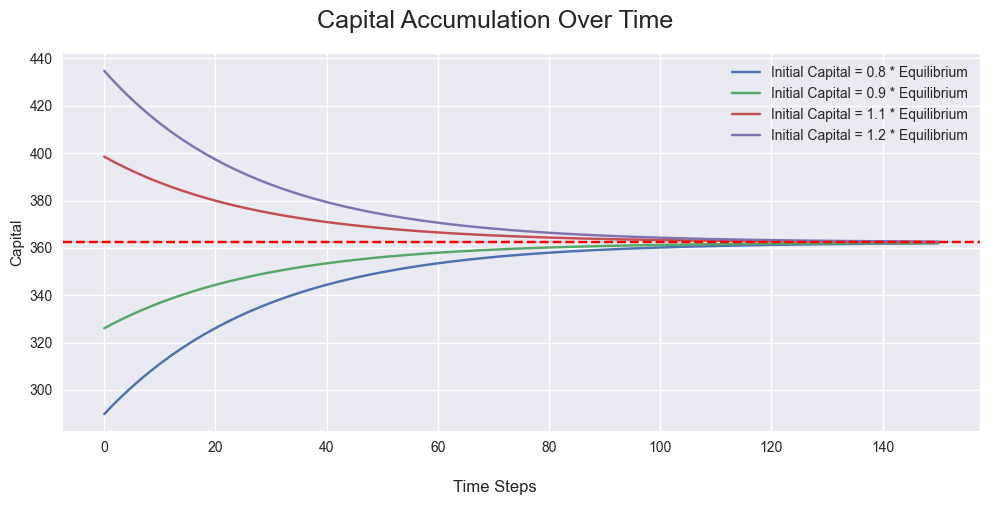

In [7]:
# given initial capital and labor, simulate the economy
parameters = {
    "a": 1,
    "alpha": 0.3,
    "depreciation": 0.05,
    "savings_rate": 0.2,
}
initial_labor = 50
eq_capital = equilibrium_capital(initial_labor, **parameters)
data = {}
for factor in [0.8, 0.9, 1.1, 1.2]:
    initial_capital = eq_capital * factor
    capital_over_time = [initial_capital]
    for t in range(150):
        new_capital = time_step(capital_over_time[-1], initial_labor, **parameters)
        capital_over_time.append(new_capital)
    data[f"Initial Capital = {factor} * Equilibrium"] = capital_over_time

fig, axes = plots.plot_time_data(data, title="Capital Accumulation Over Time", y_label="Capital")
axes[0].axhline(eq_capital, color="red", linestyle="--", label="Equilibrium Capital")
plt.show()

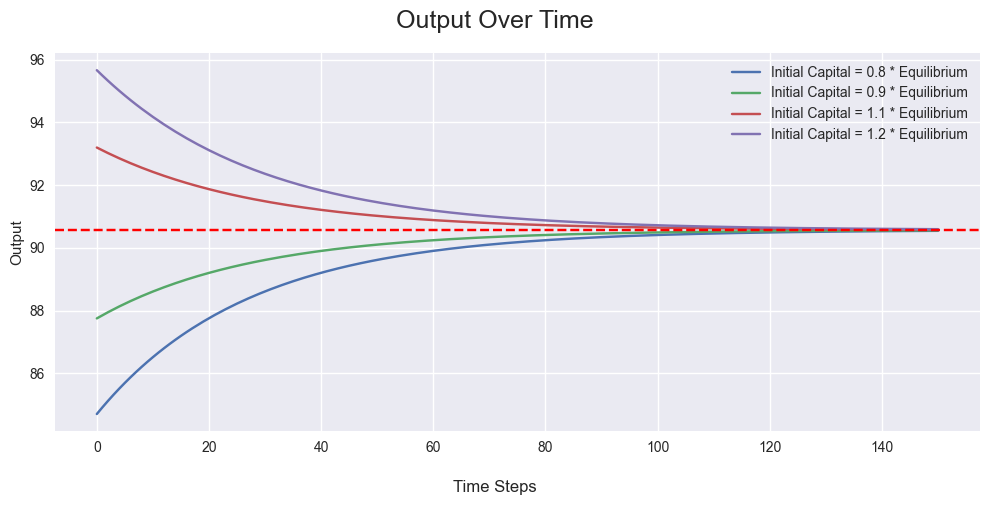

In [8]:
# Same but with production output instead of capital
data_output = {}
for factor, capital_over_time in data.items():
    output_over_time = [
        cobb_douglas(k, initial_labor, **parameters) for k in capital_over_time
    ]
    data_output[factor] = output_over_time


fig, axes = plots.plot_time_data(
    data_output, title="Output Over Time", y_label="Output"
)
axes[0].axhline(
    cobb_douglas(eq_capital, initial_labor, **parameters),
    color="red",
    linestyle="--",
    label="Equilibrium Output",
)
plt.show()

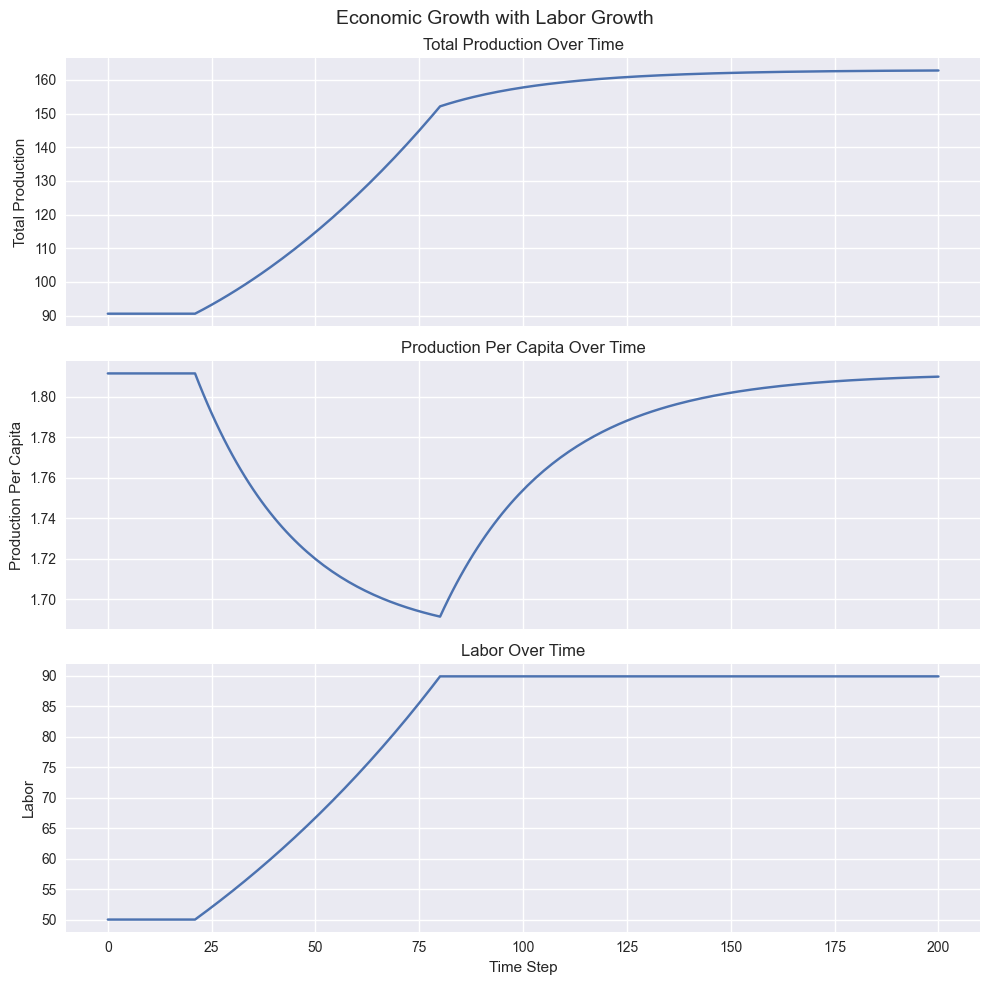

In [9]:
# labor growth over time
labor_growth_rate = 0.01 # 1% growth per time step
initial_labor = 50
labor_over_time = [initial_labor]
initial_capital = equilibrium_capital(initial_labor, **parameters)
capital_over_time = [initial_capital]
initial_production = cobb_douglas(initial_capital, initial_labor, **parameters)
production_over_time = [initial_production]
production_per_capita_over_time = [initial_production / initial_labor]
for t in range(200):
    new_labor = labor_over_time[-1] * (1 + labor_growth_rate) if t > 20 and t < 80 else labor_over_time[-1]
    labor_over_time.append(new_labor)
    new_capital = time_step(capital_over_time[-1], labor_over_time[-1], **parameters)
    capital_over_time.append(new_capital)
    new_production = cobb_douglas(new_capital, new_labor, **parameters)
    production_over_time.append(new_production)
    production_per_capita_over_time.append(new_production / new_labor)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 10), sharex=True)

ax1.plot(production_over_time)
ax1.set_title("Total Production Over Time")
ax1.set_ylabel("Total Production")

ax2.plot(production_per_capita_over_time)
ax2.set_title("Production Per Capita Over Time")
ax2.set_ylabel("Production Per Capita")

ax3.plot(labor_over_time)
ax3.set_title("Labor Over Time")
ax3.set_xlabel("Time Step")
ax3.set_ylabel("Labor")

fig.suptitle("Economic Growth with Labor Growth", fontsize=14)
fig.tight_layout()
plt.show()


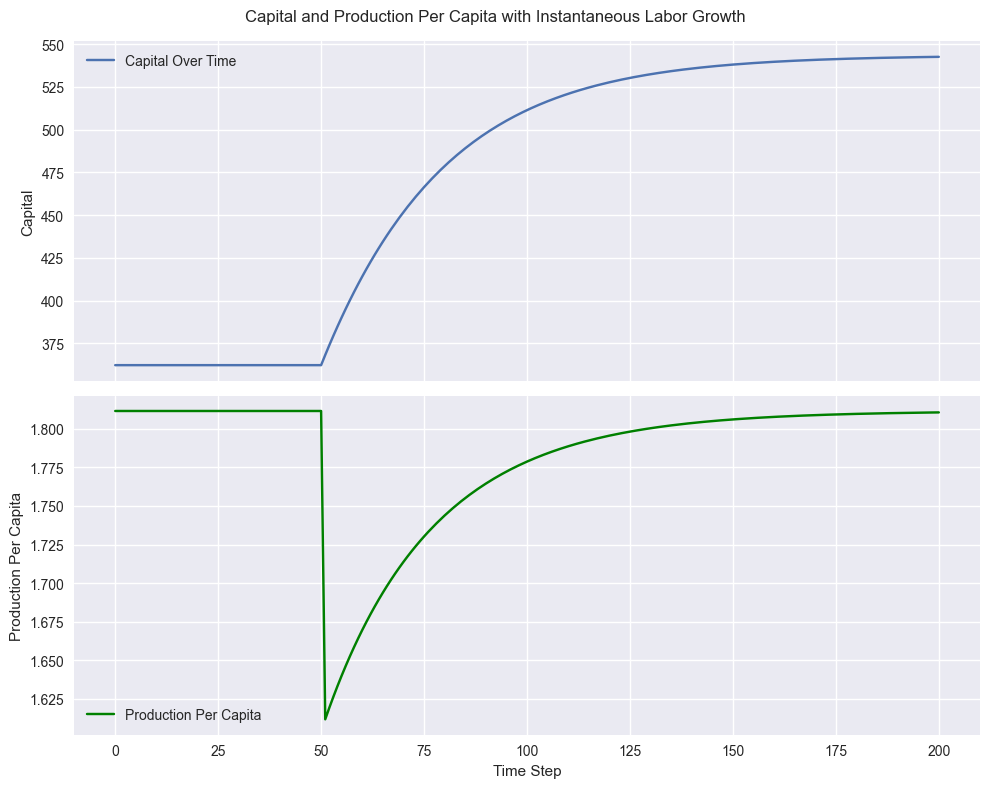

In [10]:
# simulation of instantaneous labor growth at a given step
labor_growth_time_step = 50
labor_growth_rate = 0.5  # 50% growth at the specified time step
initial_labor = 50
labor_over_time = [initial_labor]
initial_capital = equilibrium_capital(initial_labor, **parameters)
capital_over_time = [initial_capital]
initial_production = cobb_douglas(initial_capital, initial_labor, **parameters)
production_per_capita_over_time = [initial_production / initial_labor]
for t in range(200):
    if t == labor_growth_time_step:
        new_labor = labor_over_time[-1] * (1 + labor_growth_rate)
    else:
        new_labor = labor_over_time[-1]
    labor_over_time.append(new_labor)
    new_capital = time_step(capital_over_time[-1], new_labor, **parameters)
    capital_over_time.append(new_capital)
    new_production = cobb_douglas(new_capital, new_labor, **parameters)
    production_per_capita_over_time.append(new_production / new_labor)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

ax1.plot(capital_over_time, label="Capital Over Time")
ax1.set_ylabel("Capital")
ax1.legend()

ax2.plot(production_per_capita_over_time, color="green", label="Production Per Capita")
ax2.set_xlabel("Time Step")
ax2.set_ylabel("Production Per Capita")
ax2.legend()

fig.suptitle("Capital and Production Per Capita with Instantaneous Labor Growth")
fig.tight_layout()
plt.show()

## The view from the perspective of a single representative firm

$P = \text{profit}$

$P = R - C$
where $R$ is revenue and $C$ is cost.

$R = Y$
where $Y$ is output, in units of currency.

$C = wL + rK$
where $w$ is the wage rate, $L$ is labor, $r$ is the rental rate of capital, and $K$ is capital.

therefore:
$P = Y - wL - rK$

But in order for a firm to to achieve revenue, products must be sold. Since this is a representative firm, the revenue must come from selling to the representative consumer, who obtain their income from labor and capital. Therefore, the revenue must be equal to the cost of production:

$Y \leq wL + rK$


In [11]:
def labor_from_production(production, capital, a=1, alpha=0.3, labor_efficiency=1, **kwargs):
    return (production / (a * (capital**alpha))) ** (1 / (1 - alpha)) / labor_efficiency

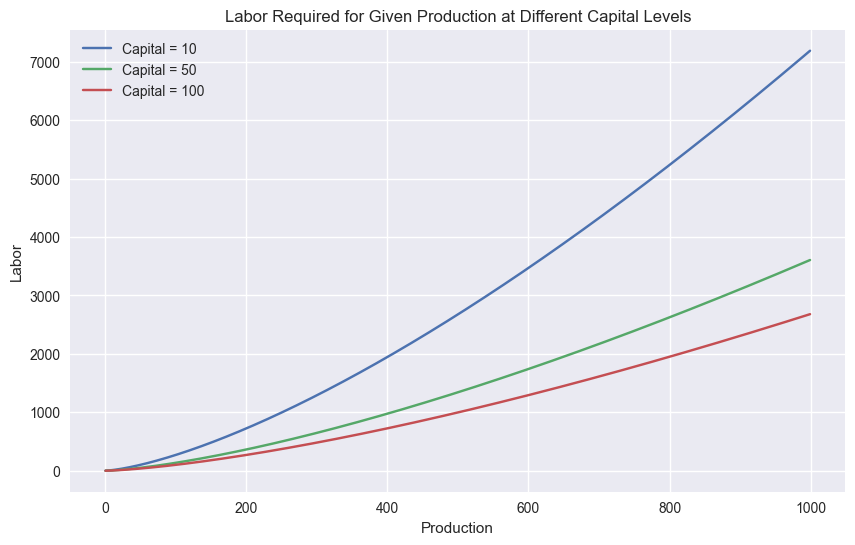

In [12]:
# plot labor from production as a function of production for a given values of capital
capital_values = [10, 50, 100]
production_values = range(1, 1000)
plt.figure(figsize=(10, 6))
for capital in capital_values:
    labor_values = [
        labor_from_production(p, capital, **parameters) for p in production_values
    ]
    plt.plot(production_values, labor_values, label=f"Capital = {capital}")
plt.xlabel("Production")
plt.ylabel("Labor")
plt.title("Labor Required for Given Production at Different Capital Levels")
plt.legend()
plt.show()

In [13]:
def equilibrium_wage(
    capital, labor, a=1, alpha=0.3, labor_efficiency=1, capital_cost=0.1, **kwargs
):
    production = cobb_douglas(
        capital, labor, a, alpha, labor_efficiency=labor_efficiency
    )
    return (production - capital_cost * capital) / labor

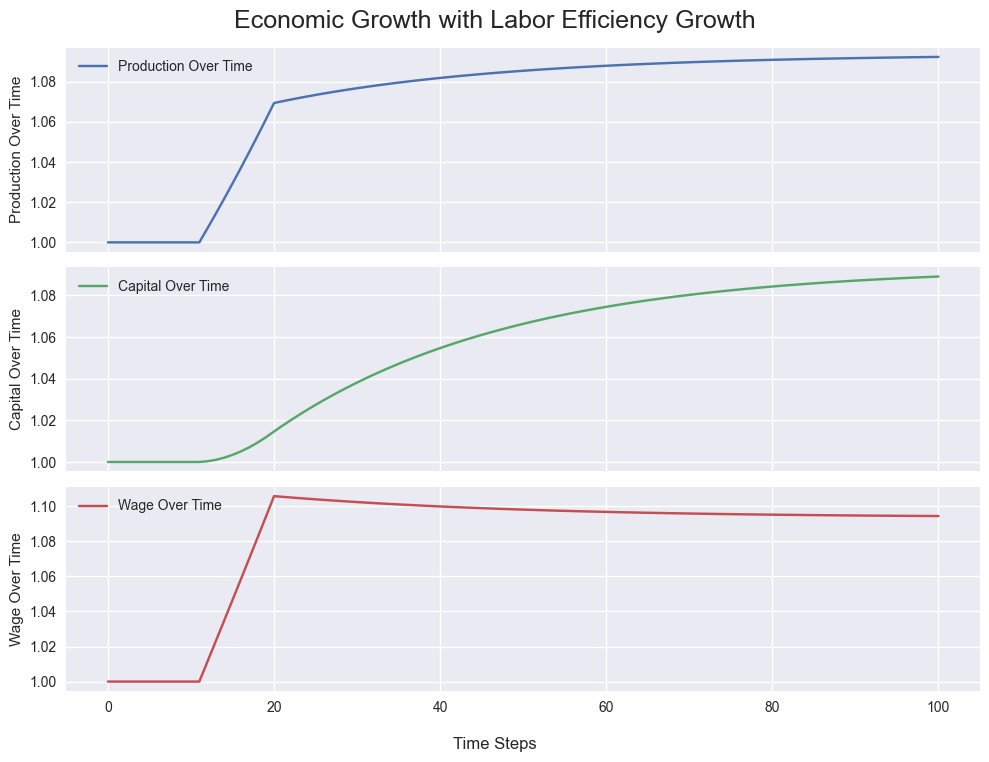

In [14]:
# labor efficiency growth step at time 10

labor_efficiency_growth_start_time_step = 10
labor_efficiency_growth_stop_time_step = 20
labor_efficiency_growth_rate = 0.01

initial_labor = 50
labor_over_time = [initial_labor]
initial_capital = equilibrium_capital(initial_labor, **parameters)
capital_over_time = [initial_capital]
initial_production = cobb_douglas(initial_capital, initial_labor, **parameters)
production_over_time = [initial_production]
wage_over_time = [equilibrium_wage(initial_capital, initial_labor, **parameters)]

labor_efficiency_over_time = [1]
for t in range(100):
    if (
        t > labor_efficiency_growth_start_time_step
        and t < labor_efficiency_growth_stop_time_step
    ):
        new_labor_efficiency = labor_efficiency_over_time[-1] * (
            1 + labor_efficiency_growth_rate
        )
    else:
        new_labor_efficiency = labor_efficiency_over_time[-1]
    labor_efficiency_over_time.append(new_labor_efficiency)
    new_labor = labor_over_time[-1]
    labor_over_time.append(new_labor)
    new_capital = time_step(
        capital_over_time[-1],
        new_labor,
        labor_efficiency=new_labor_efficiency,
        **parameters,
    )
    capital_over_time.append(new_capital)
    new_production = cobb_douglas(
        new_capital, new_labor, labor_efficiency=new_labor_efficiency, **parameters
    )
    production_over_time.append(new_production)
    new_wage = equilibrium_wage(
        new_capital,
        new_labor,
        labor_efficiency=new_labor_efficiency,
        **parameters,
    )
    wage_over_time.append(new_wage)

fig, axes = plots.plot_time_data(
    {
        "Production Over Time": production_over_time,
        "Capital Over Time": capital_over_time,
        "Wage Over Time": wage_over_time,
    },
    title="Economic Growth with Labor Efficiency Growth",
    separate=True,
    normalize_t0=True,
)

plt.show()

In [23]:
def simulate_labor_efficiency_growth(
    parameters,
    labor_efficiency_growth_time_step=20,
    labor_efficiency_growth_rate=0.05,
    wage_growth_rate=0.0,
    capital_cost=0.1,
    n_steps=100,
):
    initial_labor = 50
    initial_capital = equilibrium_capital(initial_labor, **parameters)
    initial_production = cobb_douglas(initial_capital, initial_labor, **parameters)
    initial_wage = equilibrium_wage(
        initial_capital, initial_labor, labor_efficiency=1, **parameters
    )

    labor_over_time = [initial_labor]
    capital_over_time = [initial_capital]
    production_over_time = [initial_production]
    wage_over_time = [initial_wage]
    labor_efficiency_over_time = [1]

    for t in range(n_steps):
        if t == labor_efficiency_growth_time_step:
            new_labor_efficiency = labor_efficiency_over_time[-1] * (
                1 + labor_efficiency_growth_rate
            )
        else:
            new_labor_efficiency = labor_efficiency_over_time[-1]
        labor_efficiency_over_time.append(new_labor_efficiency)

        demanded_production = (
            wage_over_time[-1] * labor_over_time[-1]
            + capital_cost * capital_over_time[-1]
        )

        required_labor = labor_from_production(
            demanded_production,
            capital_over_time[-1],
            labor_efficiency=new_labor_efficiency,
            **parameters,
        )
        labor_over_time.append(required_labor)
        new_capital = time_step(
            capital_over_time[-1],
            required_labor,
            labor_efficiency=new_labor_efficiency,
            **parameters,
        )
        capital_over_time.append(new_capital)
        production_over_time.append(demanded_production)

        new_wage = wage_over_time[-1] * (1 + wage_growth_rate)
        wage_over_time.append(new_wage)

    return {
        "Production": production_over_time,
        "Wage": wage_over_time,
        "Labor": labor_over_time,
        "Capital": capital_over_time,
    }

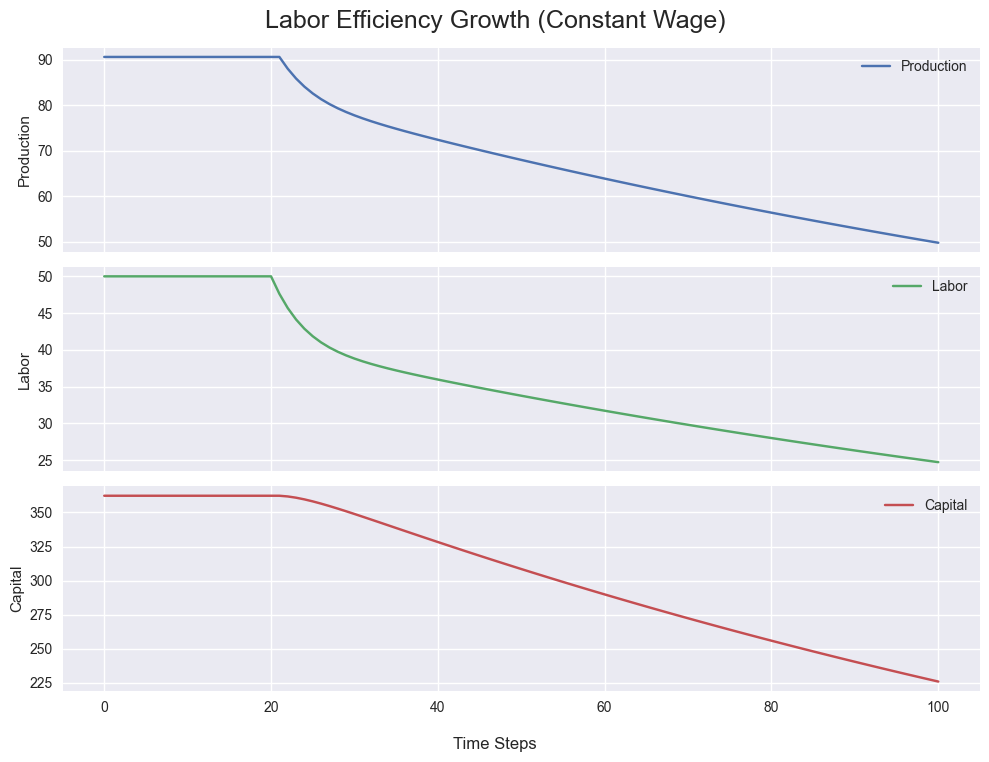

In [24]:
# labor efficiency growth step at time 50
# constant wage

data = simulate_labor_efficiency_growth(parameters, wage_growth_rate=0.0)
data = {k: v for k, v in data.items() if k in ["Production", "Labor", "Capital"]}
plots.plot_time_data(data, title="Labor Efficiency Growth (Constant Wage)", separate=True)
plt.show()

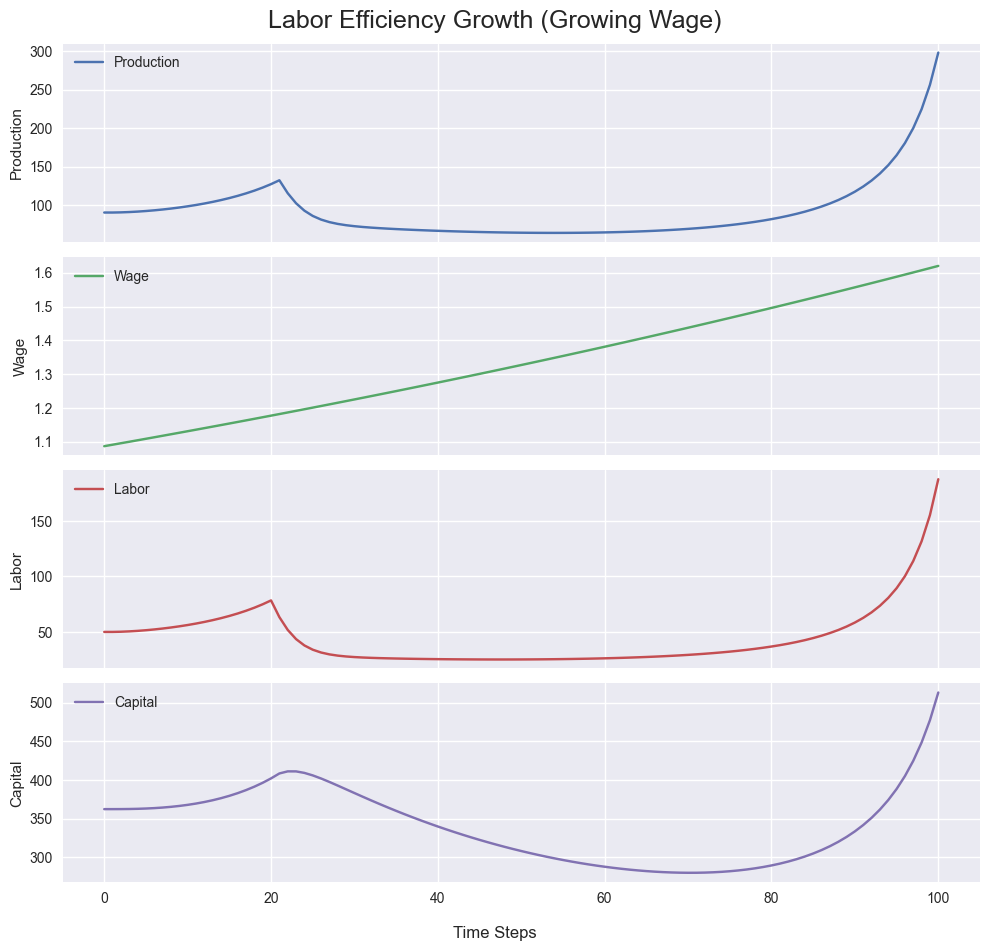

In [17]:
# labor efficiency growth step at time 50
# growing wage

data = simulate_labor_efficiency_growth(parameters, wage_growth_rate=0.004, labor_efficiency_growth_rate=0.3)
plots.plot_time_data(data, title="Labor Efficiency Growth (Growing Wage)", separate=True)
plt.show()

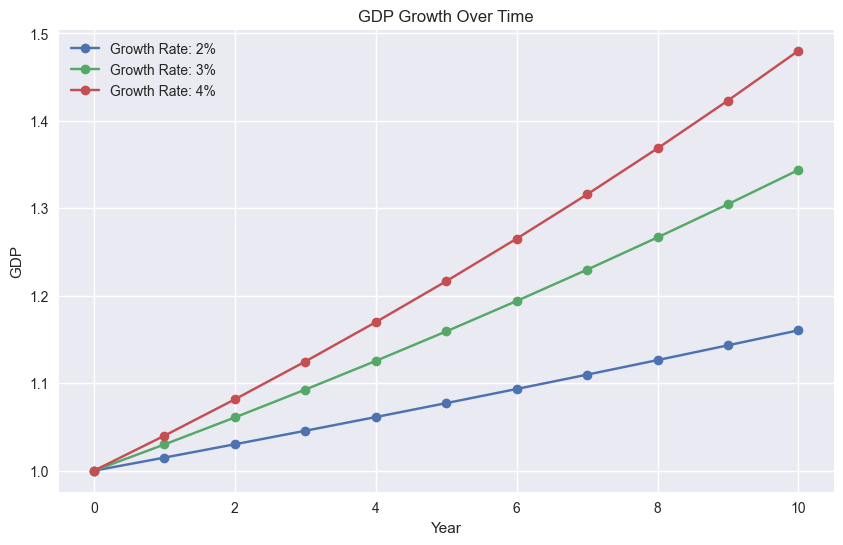

In [18]:
# the relationship between growth rate and overall productivity over a 10 year horizon.

gpd_growth_rates = [0.015, 0.03, 0.04] 
initial_gdp = 1
data = {}
for growth_rate in gpd_growth_rates:
    gdp_over_time = [initial_gdp]
    for t in range(10):
        new_gdp = gdp_over_time[-1] * (1 + growth_rate)
        gdp_over_time.append(new_gdp)
    data[growth_rate] = gdp_over_time

plt.figure(figsize=(10, 6))
for growth_rate, gdp_over_time in data.items():
    plt.plot(gdp_over_time, marker="o", label=f"Growth Rate: {growth_rate*100:.0f}%")

plt.title("GDP Growth Over Time")
plt.xlabel("Year")
plt.ylabel("GDP")
plt.legend()
plt.show()